<a href="https://colab.research.google.com/github/Jquishpeq923/Machine-Learning-6-SIN-A-Mar-Jul-2026/blob/homework_Machine_Learning/Copia_de_linear_regression_taxi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Copyright 2023 Google LLC. Double-click here for license information.
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Colabs

Machine Learning Crash Course uses Colaboratories (Colabs) for all programming exercises. Colab is Google's implementation of [Jupyter Notebook](https://jupyter.org/). For more information about Colabs and how to use them, go to [Welcome to Colaboratory](https://research.google.com/colaboratory).

# Linear Regression
In this Colab you will use a real dataset to train a model to predict the fare of a taxi ride in Chicago, Illinois.

## Learning Objectives
After completing this Colab, you'll be able to:

  * Read a .csv file into a [pandas](https://developers.google.com/machine-learning/glossary/#pandas) DataFrame.
  * Explore a [dataset](https://developers.google.com/machine-learning/glossary/#data_set) with Python visualization libraries.
  * Experiment with different [features](https://developers.google.com/machine-learning/glossary/#feature) to build a linear regression model.
  * Tune the model's [hyperparameters](https://developers.google.com/machine-learning/glossary/#hyperparameter).
  * Compare training runs using [root mean squared error](https://developers.google.com/machine-learning/glossary/#root-mean-squared-error-rmse) and [loss curves](https://developers.google.com/machine-learning/glossary/#loss-curve).

## Dataset Description
The [dataset for this exercise](https://storage.mtls.cloud.google.com/mlcc-nextgen-internal/chicago_taxi_train.csv) is derived from the [City of Chicago Taxi Trips dataset](https://data.cityofchicago.org/Transportation/Taxi-Trips/wrvz-psew). The data for this exercise is a subset of the Taxi Trips data, and focuses on a two-day period in May of 2022.

# Part 1 - Setup Exercise


---

## Load required modules

This exercise depends on several Python libraries to help with data manipulation, machine learning tasks, and data visualization.

**Instructions**
1. Run the **Install required libraries** code cell (below).
1. Run the **Load dependencies** code cell (below).

In [84]:
#@title Install required libraries

!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

print('\n\nAll requirements successfully installed.')



All requirements successfully installed.


In [85]:
#@title Code - Load dependencies

# data
import numpy as np
import pandas as pd

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px

## Load the dataset


The following code cell loads the dataset and creates a pandas DataFrame.

You can think of a DataFrame like a spreadsheet with rows and columns. The rows represent individual data examples, and the columns represent the attributes associated with each example.

In [86]:
# @title
chicago_taxi_dataset = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

## Update the dataframe

The following code cell updates the DataFrame to use only specific columns from the dataset.

Notice that that output shows just a sample of the dataset, but there should be enough information for you to identify the features associated with the dataset, and have a look at the actual data for a few examples.

In [87]:
#@title Code - Read dataset

# Updates dataframe to use specific columns.
training_df = chicago_taxi_dataset.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]

print('Read dataset completed successfully.')
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.head(200)

Read dataset completed successfully.
Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


# Part 2 - Dataset Exploration


---

## View dataset statistics

A large part of most machine learning projects is getting to know your data. In this step, you will use the ``DataFrame.describe`` method to view descriptive statistics about the dataset and answer some important questions about the data.

**Instructions**
1. Run the **View dataset statistics** code cell.
1. Inspect the output and answer these questions:
  * What is the maximum fare?
  * What is the mean distance across all trips?
  * How many cab companies are in the dataset?
  * What is the most frequent payment type?
  * Are any features missing data?
1. Run the code **View answers to dataset statistics** code cell to check your answers.


You might be wondering why there are groups of `NaN` (not a number) values listed in the output. When working with data in Python, you may see this value if the result of a calculation can not be computed or if there is missing information. For example, in the taxi dataset `PAYMENT_TYPE` and `COMPANY` are non-numeric, categorical features; numeric information such as mean and max do not make sense for categorical features so the output displays `NaN`.

In [88]:
#@title Code - View dataset statistics

print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [89]:
#@title Double-click or run to view answers about dataset statistics

answer = '''
What is the maximum fare? 				              Answer: $159.25
What is the mean distance across all trips? 		Answer: 8.2895 miles
How many cab companies are in the dataset? 		  Answer: 31
What is the most frequent payment type? 		    Answer: Credit Card
Are any features missing data? 				          Answer: No
'''

# You should be able to find the answers to the questions about the dataset
# by inspecting the table output after running the DataFrame describe method.
#
# Run this code cell to verify your answers.

# What is the maximum fare?
max_fare = training_df['FARE'].max()
print("What is the maximum fare? 				Answer: ${fare:.2f}".format(fare = max_fare))

# What is the mean distance across all trips?
mean_distance = training_df['TRIP_MILES'].mean()
print("What is the mean distance across all trips? 		Answer: {mean:.4f} miles".format(mean = mean_distance))

# How many cab companies are in the dataset?
num_unique_companies =  training_df['COMPANY'].nunique()
print("How many cab companies are in the dataset? 		Answer: {number}".format(number = num_unique_companies))

# What is the most frequent payment type?
most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
print("What is the most frequent payment type? 		Answer: {type}".format(type = most_freq_payment_type))

# Are any features missing data?
missing_values = training_df.isnull().sum().sum()
print("Are any features missing data? 				Answer:", "No" if missing_values == 0 else "Yes")

What is the maximum fare? 				Answer: $159.25
What is the mean distance across all trips? 		Answer: 8.2895 miles
How many cab companies are in the dataset? 		Answer: 31
What is the most frequent payment type? 		Answer: Credit Card
Are any features missing data? 				Answer: No


## Generate a correlation matrix

An important part of machine learning is determining which [features](https://developers.google.com/machine-learning/glossary/#feature) correlate with the [label](https://developers.google.com/machine-learning/glossary/#label). If you have ever taken a taxi ride before, your experience is probably telling you that the fare is typically associated with the distance traveled and the duration of the trip. But, is there a way for you to learn more about how well these features correlate to the fare (label)?

In this step, you will use a **correlation matrix** to identify features whose values correlate well with the label. Correlation values have the following meanings:

  * **`1.0`**: perfect positive correlation; that is, when one attribute rises, the other attribute rises.
  * **`-1.0`**: perfect negative correlation; that is, when one attribute rises, the other attribute falls.
  * **`0.0`**: no correlation; the two columns [are not linearly related](https://en.wikipedia.org/wiki/Correlation_and_dependence#/media/File:Correlation_examples2.svg).

In general, the higher the absolute value of a correlation value, the greater its predictive power.

**Instructions**

1. Inspect the code in the **View correlation matrix** code cell.
1. Run the **View correlation matrix** code cell and inspect the output.
1. **Check your understanding** by answering these questions:
  * Which feature correlates most strongly to the label FARE?
  * Which feature correlates least strongly to the label FARE?


In [90]:
#@title Code - View correlation matrix
training_df.corr(numeric_only = True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [91]:
#@title Double-click to view answers about the correlation matrix

# Which feature correlates most strongly to the label FARE?
# ---------------------------------------------------------
answer = '''
The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.
'''
print(answer)


# Which feature correlates least strongly to the label FARE?
# -----------------------------------------------------------
answer = '''The feature with the weakest correlation to the FARE is TIP_RATE.'''
print(answer)


The feature with the strongest correlation to the FARE is TRIP_MILES.
As you might expect, TRIP_MILES looks like a good feature to start with to train
the model. Also, notice that the feature TRIP_SECONDS has a strong correlation
with fare too.

The feature with the weakest correlation to the FARE is TIP_RATE.


## Visualize relationships in dataset

Sometimes it is helpful to visualize relationships between features in a dataset; one way to do this is with a pair plot. A **pair plot** generates a grid of pairwise plots to visualize the relationship of each feature with all other features all in one place.

**Instructions**
1. Run the **View pair plot** code cell.

In [92]:
#@title Code - View pairplot
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])

# Part 3 - Train Model


---

## Define functions to build and train a model

The code you need to build and train your model is in the **Define ML functions** code cell. If you would like to explore this code, expand the code cell and take a look.

**Instructions**
1. Run the **Define ML functions** code cell.

In [93]:
#@title Code - Define ML functions

def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


## Train a model with one feature

In this step you will train a model to predict the cost of the fare using a **single feature**. Earlier, you saw that `TRIP_MILES` (distance) correlates most strongly with the ``FARE``, so let's start with `TRIP_MILES` as the feature for your first training run.

**Instructions**

1. Run the **Experiment 1** code cell to build your model with one feature.
1. Review the output from the training run
1. **Check your understanding** by answering these questions:
  * How many epochs did it take to converge on the final model?
  * How well does the model fit the sample data?

During training, you should see the root mean square error (RMSE) in the output. The units for RMSE are the same as the units for the label (dollars). In other words, you can use the RMSE to determine how far off, on average, the predicted fares are in dollars from the observed values.

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 166.8730 - rmse: 12.8762
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 44.3898 - rmse: 6.6327
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 18.8724 - rmse: 4.3356
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 18.8379 - rmse: 4.3360
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 15.9127 - rmse: 3.9801
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.1287 - rmse: 3.8751
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.0177 - rmse: 3.7292
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.9983 - rmse: 3.8692
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.0473 - rmse: 3.8691
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.3682 - rmse: 3.6438
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.3475 - rmse: 3.6410
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.3269 - rmse: 3.6456

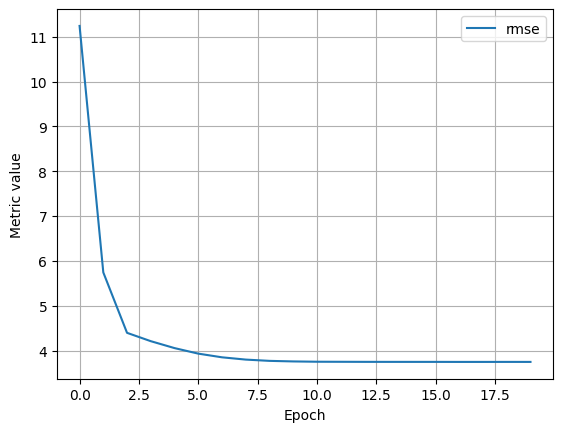

In [94]:
#@title Code - Experiment 1

# The following variables are the hyperparameters.
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')

In [95]:
#@title Double-click to view answers for training model with one feature

# How many epochs did it take to converge on the final model?
# -----------------------------------------------------------------------------
answer = """
Use the loss curve to see where the loss begins to level off during training.

With this set of hyperparameters:

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

it takes about 5 epochs for the training run to converge to the final model.
"""
print(answer)

# How well does the model fit the sample data?
# -----------------------------------------------------------------------------
answer = '''
It appears from the model plot that the model fits the sample data fairly well.
'''
print(answer)


Use the loss curve to see where the loss begins to level off during training.

With this set of hyperparameters:

  learning_rate = 0.001
  epochs = 20
  batch_size = 50

it takes about 5 epochs for the training run to converge to the final model.


It appears from the model plot that the model fits the sample data fairly well.



## Experiment with hyperparameters

It is common with machine learning to run multiple experiments to find the best set of hyperparmeters to train your model. In this step, try varying the hyperparameters one by one with this set of experiments:

* *Experiment 1:* **Increase** the learning rate to **``1.0``** (batch size at ``50``).
* *Experiment 2:* **Decrease** the learning rate to **``0.0001``** (batch size at ``50``).
* *Experiment 3:* **Increase** the batch size to **``500``** (learning rate at ``0.001``).

**Instructions**
1. Update the hyperparameter values in the **Experiment 2** code cell according to the experiment.
2. Run the **Experiment 2** code cell.
3. After the training run, examine the output and note any differences you see in the loss curve or model output.
4. Repeat steps 1 - 3 for each hyperparameter experiment.
5. **Check your understanding** by answering these questions:
  * How did raising the learning rate impact your ability to train the model?
  * How did lowering the learning rate impact your ability to train the model?
  * Did changing the batch size effect your training results?


## Experiment 1 Hyperparameter Variations (Feature: TRIP_MILES)

### Experiment 1.1: High Learning Rate (1.0)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 55.0518 - rmse: 7.3364
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 45.6528 - rmse: 6.7517
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 47.4106 - rmse: 6.8711
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 48.3544 - rmse: 6.9485
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 46.6909 - rmse: 6.8229
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49.3663 - rmse: 7.0129
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49.6096 - rmse: 7.0334
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 45.7577 - rmse: 6.7526
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.3682 - rmse: 6.9491
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 48.2600 - rmse: 6.9445
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46.0091 - rmse: 6.7762
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.0184 - rmse: 6.8546
E

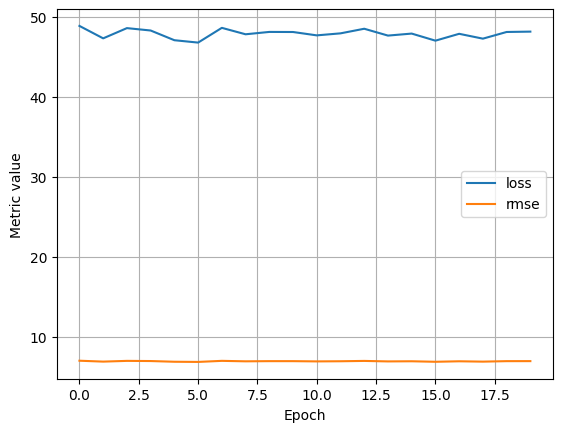

In [97]:
#@title Code - Experiment 1.1 (High Learning Rate)

# The following variables are the hyperparameters.
settings_1_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 1.0, # High learning rate
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1_1 = create_model(settings_1_1, metrics_exp)

experiment_1_1 = train_model('one_feature_lr_high', model_1_1, training_df, 'FARE', settings_1_1)

ml_edu.results.plot_experiment_metrics(experiment_1_1, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_1_1, training_df, 'FARE')

### Experiment 1.2: Low Learning Rate (0.0001)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 253.2044 - rmse: 15.9096
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 226.2115 - rmse: 15.0399
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 205.1311 - rmse: 14.3221
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 188.5753 - rmse: 13.7301
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 165.5209 - rmse: 12.8652
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 150.0300 - rmse: 12.2482
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 135.3557 - rmse: 11.6338
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 121.1164 - rmse: 11.0031
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 104.1662 - rmse: 10.2057
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 92.0625 - rmse: 9.5939
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 79.8013 - rmse: 8.9328
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 68.124

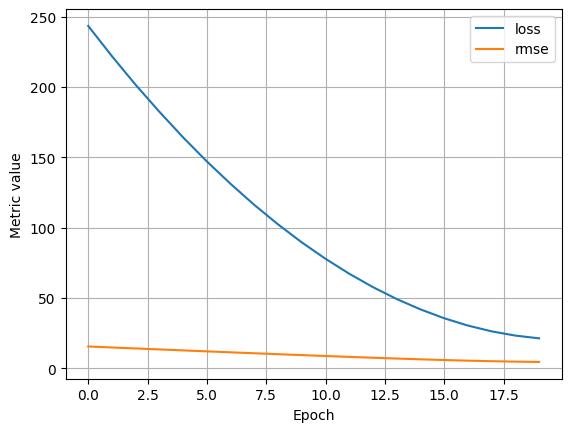

In [98]:
#@title Code - Experiment 1.2 (Low Learning Rate)

# The following variables are the hyperparameters.
settings_1_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.0001, # Low learning rate
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1_2 = create_model(settings_1_2, metrics_exp)

experiment_1_2 = train_model('one_feature_lr_low', model_1_2, training_df, 'FARE', settings_1_2)

ml_edu.results.plot_experiment_metrics(experiment_1_2, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_1_2, training_df, 'FARE')

### Experiment 1.3: High Number of Epochs (100)

Epoch 1/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 637.9581 - rmse: 25.2359
Epoch 2/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 330.4734 - rmse: 18.1469
Epoch 3/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 123.8761 - rmse: 11.0965
Epoch 4/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 29.7874 - rmse: 5.4326
Epoch 5/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17.0346 - rmse: 4.1141
Epoch 6/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 15.5913 - rmse: 3.9412
Epoch 7/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 15.7684 - rmse: 3.9598
Epoch 8/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 12.2762 - rmse: 3.4921
Epoch 9/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.2813 - rmse: 3.7718
Epoch 10/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12.5637 - rmse: 3.5333
Epoch 11/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.1016 - rmse: 3.7445
Epoch 12/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 13.622

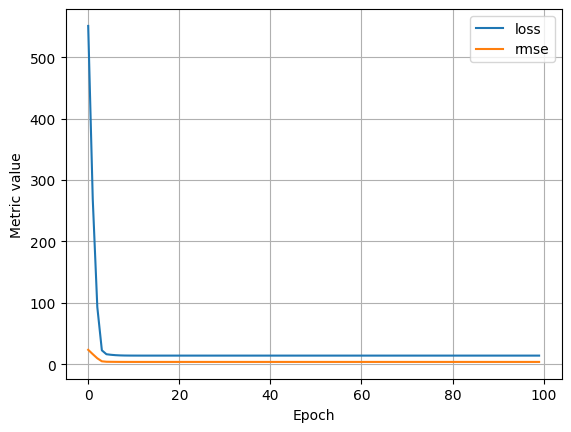

In [99]:
#@title Code - Experiment 1.3 (High Epochs)

# The following variables are the hyperparameters.
settings_1_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 100, # High number of epochs
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1_3 = create_model(settings_1_3, metrics_exp)

experiment_1_3 = train_model('one_feature_epochs_high', model_1_3, training_df, 'FARE', settings_1_3)

ml_edu.results.plot_experiment_metrics(experiment_1_3, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_1_3, training_df, 'FARE')

### Experiment 1.4: Low Number of Epochs (5)

Epoch 1/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 833.1700 - rmse: 28.8493
Epoch 2/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 477.3115 - rmse: 21.8212
Epoch 3/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 218.2746 - rmse: 14.7433
Epoch 4/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 64.6183 - rmse: 8.0036
Epoch 5/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 17.8894 - rmse: 4.2232
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


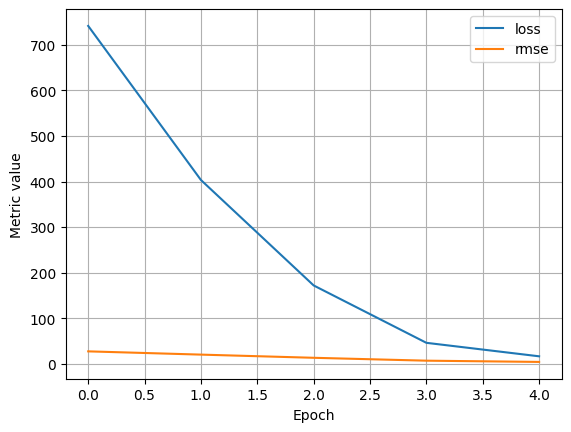

In [100]:
#@title Code - Experiment 1.4 (Low Epochs)

# The following variables are the hyperparameters.
settings_1_4 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 5, # Low number of epochs
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1_4 = create_model(settings_1_4, metrics_exp)

experiment_1_4 = train_model('one_feature_epochs_low', model_1_4, training_df, 'FARE', settings_1_4)

ml_edu.results.plot_experiment_metrics(experiment_1_4, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_1_4, training_df, 'FARE')

### Experiment 1.5: High Batch Size (500)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2183.8948 - rmse: 46.7314
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2137.4460 - rmse: 46.2318
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2047.9448 - rmse: 45.2528
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1969.5476 - rmse: 44.3777
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1894.1901 - rmse: 43.5211
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1876.5820 - rmse: 43.3189
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1790.7500 - rmse: 42.3168
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1717.1166 - rmse: 41.4376
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1673.5431 - rmse: 40.9085
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1605.2385 - rmse: 40.0644
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1562.2062 - rmse: 39.5232
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1515.4479 - rms

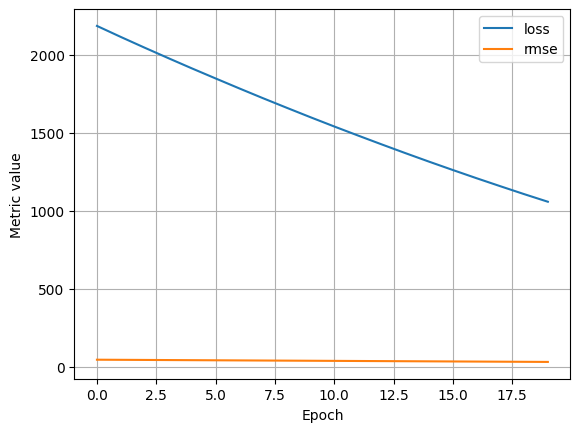

In [101]:
#@title Code - Experiment 1.5 (High Batch Size)

# The following variables are the hyperparameters.
settings_1_5 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 500, # High batch size
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1_5 = create_model(settings_1_5, metrics_exp)

experiment_1_5 = train_model('one_feature_bs_high', model_1_5, training_df, 'FARE', settings_1_5)

ml_edu.results.plot_experiment_metrics(experiment_1_5, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_1_5, training_df, 'FARE')

### Experiment 1.6: Low Batch Size (10)

Epoch 1/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 93.0797 - rmse: 9.3667
Epoch 2/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 16.4538 - rmse: 4.0391
Epoch 3/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 13.8371 - rmse: 3.7150
Epoch 4/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 13.3286 - rmse: 3.6431
Epoch 5/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 13.7058 - rmse: 3.6985
Epoch 6/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 12.6832 - rmse: 3.5543
Epoch 7/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 12.9816 - rmse: 3.5928
Epoch 8/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 14.7765 - rmse: 3.8329
Epoch 9/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 14.3678 - rmse: 3.7831
Epoch 10/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 13.0457 - rmse: 3.5944
Epoch 11/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 13.7205 - rmse: 3.6992
Epoch 12/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss

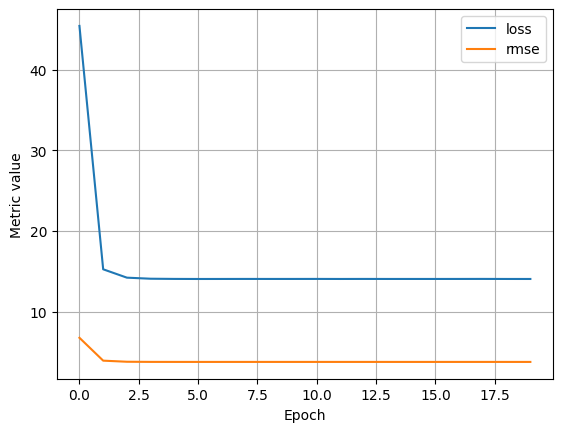

In [102]:
#@title Code - Experiment 1.6 (Low Batch Size)

# The following variables are the hyperparameters.
settings_1_6 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 10, # Low batch size
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1_6 = create_model(settings_1_6, metrics_exp)

experiment_1_6 = train_model('one_feature_bs_low', model_1_6, training_df, 'FARE', settings_1_6)

ml_edu.results.plot_experiment_metrics(experiment_1_6, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_1_6, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1250.3893 - rmse: 35.3504
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 796.0340 - rmse: 28.1973
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 440.5731 - rmse: 20.9683
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 196.9439 - rmse: 14.0038
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 55.3327 - rmse: 7.3994
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.1257 - rmse: 4.0052
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 15.4594 - rmse: 3.9183
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14.0219 - rmse: 3.7367
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.5060 - rmse: 3.5324
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.6970 - rmse: 3.6927
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.5885 - rmse: 3.8087
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.9348 - rmse:

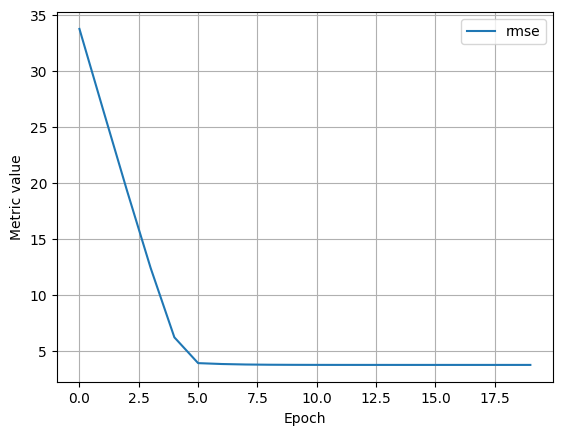

In [103]:
#@title Code - Experiment 2

# The following variables are the hyperparameters.
# TODO - Adjust these hyperparameters to see how they impact a training run.
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

In [96]:
#@title Double-click to view answers for hyperparameter experiments

# How did raising the learning rate impact your ability to train the model?
# -----------------------------------------------------------------------------
answer = """
When the learning rate is too high, the loss curve bounces around and does not
appear to be moving towards convergence with each iteration. Also, notice that
the predicted model does not fit the data very well. With a learning rate that
is too high, it is unlikely that you will be able to train a model with good
results.
"""
print(answer)

# How did lowering the learning rate impact your ability to train the model?
# -----------------------------------------------------------------------------
answer = '''
When the learning rate is too small, it may take longer for the loss curve to
converge. With a small learning rate the loss curve decreases slowly, but does
not show a dramatic drop or leveling off. With a small learning rate you could
increase the number of epochs so that your model will eventually converge, but
it will take longer.
'''
print(answer)

# Did changing the batch size effect your training results?
# -----------------------------------------------------------------------------
answer = '''
Increasing the batch size makes each epoch run faster, but as with the smaller
learning rate, the model does not converge with just 20 epochs. If you have
time, try increasing the number of epochs and eventually you should see the
model converge.
'''
print(answer)


When the learning rate is too high, the loss curve bounces around and does not
appear to be moving towards convergence with each iteration. Also, notice that
the predicted model does not fit the data very well. With a learning rate that
is too high, it is unlikely that you will be able to train a model with good
results.


When the learning rate is too small, it may take longer for the loss curve to
converge. With a small learning rate the loss curve decreases slowly, but does
not show a dramatic drop or leveling off. With a small learning rate you could
increase the number of epochs so that your model will eventually converge, but
it will take longer.


Increasing the batch size makes each epoch run faster, but as with the smaller
learning rate, the model does not converge with just 20 epochs. If you have
time, try increasing the number of epochs and eventually you should see the
model converge.



## Train a model with two features

The model you trained with the feature ``TOTAL_MILES`` demonstrates fairly strong predictive power, but is it possible to do better? In this step, try training the model with two features, ``TRIP_MILES`` and ``TRIP_MINUTES``, to see if you can improve the model. You may recall that the original dataset does not include a feature ``TRIP_MINUTES``, but this feature can be easily derived from ``TRIP_SECONDS`` as shown in the code below.*

**Instructions**
1. Review the code in **Experiment 3** code cell.
1. Run the **Experiment 3** code cell.
1. Review the output from the training run and answer these questions:
  * Does the model with two features produce better results than one using a single feature?
  * Does it make a difference if you use ``TRIP_SECONDS`` instead of ``TRIP_MINUTES``?
  * How well do you think the model comes to the ground truth fare calculation for Chicago Taxi Trips?


Notice that the scatter plot of the features vs. the label is a three dimensional (3-D) plot. This representation allows you to visualize both features and the label all together. The two features (TRIP_MILES and TRIP_MINUTES) are on the x and y axis, and the label (FARE) is on the z axis. The plot shows individual examples in the dataset as circles, and the model as a surface (plane). With this 3-D model, if the trained model is good you would expect most of the examples to land on the plane surface. The 3-D plot is interactive so you can explore the data further by clicking or dragging the plot.

## Experiment 2 Hyperparameter Variations (Feature: TRIP_MILES)

These experiments explore the impact of varying hyperparameters on the single-feature model defined in the 'Code - Experiment 2' cell. Note that the base settings for 'Experiment 2' are identical to 'Experiment 1', so the results of these variations will be very similar to Experiment 1.1-1.6.

### Experiment 2.1: High Learning Rate (1.0)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 60.1792 - rmse: 7.5762
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46.8909 - rmse: 6.8352
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.6673 - rmse: 6.8953
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.9754 - rmse: 6.9206
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.6613 - rmse: 6.9713
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 47.5842 - rmse: 6.8918
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.0362 - rmse: 6.8485
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49.5361 - rmse: 7.0341
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.0088 - rmse: 6.8427
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 47.9877 - rmse: 6.9157
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 50.4355 - rmse: 7.0835
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 46.7897 - rmse: 6.8375
E

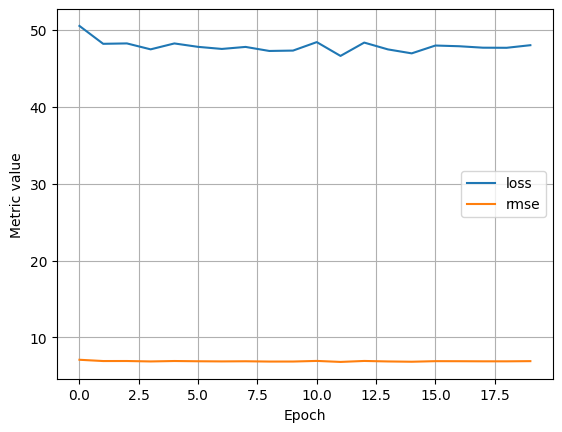

In [104]:
#@title Code - Experiment 2.1 (High Learning Rate)

# The following variables are the hyperparameters.
settings_2_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 1.0, # High learning rate
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2_1 = create_model(settings_2_1, metrics_exp)

experiment_2_1 = train_model('exp2_lr_high', model_2_1, training_df, 'FARE', settings_2_1)

ml_edu.results.plot_experiment_metrics(experiment_2_1, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_2_1, training_df, 'FARE')

### Experiment 2.2: Low Learning Rate (0.0001)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 609.9933 - rmse: 24.6968
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 572.5643 - rmse: 23.9272
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 542.4976 - rmse: 23.2911
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 504.3419 - rmse: 22.4568
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 474.5783 - rmse: 21.7842
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 447.8728 - rmse: 21.1617
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 410.9629 - rmse: 20.2717
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 383.0984 - rmse: 19.5725
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 359.7299 - rmse: 18.9659
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 329.5274 - rmse: 18.1522
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 306.0133 - rmse: 17.4928
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 28

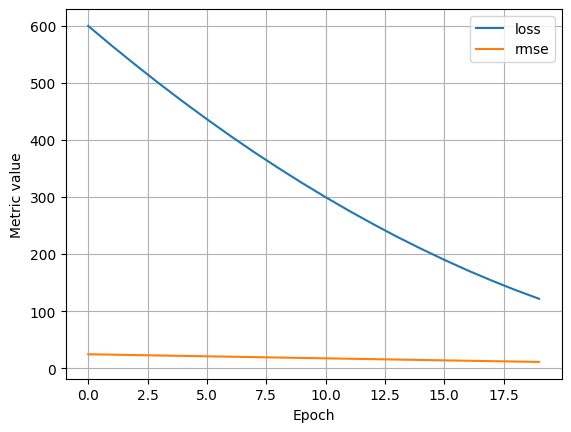

In [105]:
#@title Code - Experiment 2.2 (Low Learning Rate)

# The following variables are the hyperparameters.
settings_2_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.0001, # Low learning rate
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2_2 = create_model(settings_2_2, metrics_exp)

experiment_2_2 = train_model('exp2_lr_low', model_2_2, training_df, 'FARE', settings_2_2)

ml_edu.results.plot_experiment_metrics(experiment_2_2, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_2_2, training_df, 'FARE')

### Experiment 2.3: High Number of Epochs (100)

Epoch 1/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1884.4508 - rmse: 43.4050
Epoch 2/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1346.0217 - rmse: 36.6731
Epoch 3/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 852.7982 - rmse: 29.1888
Epoch 4/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 490.8321 - rmse: 22.1336
Epoch 5/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 226.5118 - rmse: 15.0206
Epoch 6/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 72.0773 - rmse: 8.4339
Epoch 7/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.1732 - rmse: 4.0104
Epoch 8/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.1936 - rmse: 3.7612
Epoch 9/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.8564 - rmse: 3.8511
Epoch 10/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.6152 - rmse: 3.8185
Epoch 11/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 14.7503 - rmse: 3.8374
Epoch 12/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 

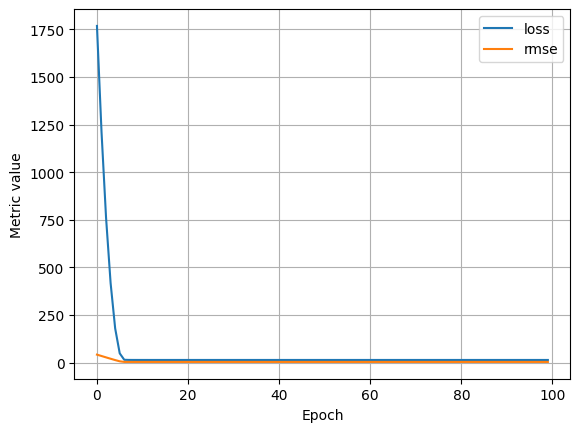

In [106]:
#@title Code - Experiment 2.3 (High Epochs)

# The following variables are the hyperparameters.
settings_2_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 100, # High number of epochs
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2_3 = create_model(settings_2_3, metrics_exp)

experiment_2_3 = train_model('exp2_epochs_high', model_2_3, training_df, 'FARE', settings_2_3)

ml_edu.results.plot_experiment_metrics(experiment_2_3, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_2_3, training_df, 'FARE')

### Experiment 2.4: Low Number of Epochs (5)

Epoch 1/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1525.8715 - rmse: 39.0364
Epoch 2/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1001.5170 - rmse: 31.6299
Epoch 3/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 588.7831 - rmse: 24.2442
Epoch 4/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 293.9148 - rmse: 17.1149
Epoch 5/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 105.6202 - rmse: 10.2385
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


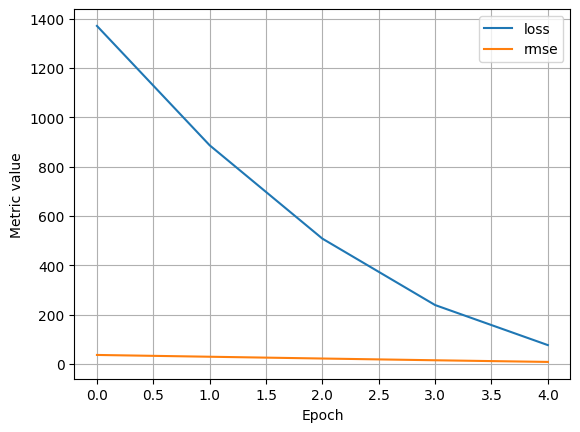

In [107]:
#@title Code - Experiment 2.4 (Low Epochs)

# The following variables are the hyperparameters.
settings_2_4 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 5, # Low number of epochs
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2_4 = create_model(settings_2_4, metrics_exp)

experiment_2_4 = train_model('exp2_epochs_low', model_2_4, training_df, 'FARE', settings_2_4)

ml_edu.results.plot_experiment_metrics(experiment_2_4, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_2_4, training_df, 'FARE')

### Experiment 2.5: High Batch Size (500)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 654.3410 - rmse: 25.5799
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 614.5044 - rmse: 24.7888
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 583.8425 - rmse: 24.1621
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 545.7314 - rmse: 23.3599
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 508.9178 - rmse: 22.5591
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 475.0456 - rmse: 21.7950
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 445.8678 - rmse: 21.1153
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 421.8926 - rmse: 20.5386
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 388.0083 - rmse: 19.6975
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 361.3173 - rmse: 19.0079
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 333.6046 - rmse: 18.2643
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 304.2545 - rmse: 17.4426
E

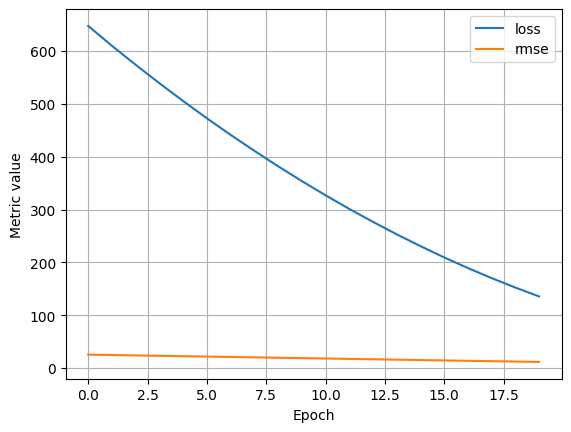

In [108]:
#@title Code - Experiment 2.5 (High Batch Size)

# The following variables are the hyperparameters.
settings_2_5 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 500, # High batch size
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2_5 = create_model(settings_2_5, metrics_exp)

experiment_2_5 = train_model('exp2_bs_high', model_2_5, training_df, 'FARE', settings_2_5)

ml_edu.results.plot_experiment_metrics(experiment_2_5, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_2_5, training_df, 'FARE')

### Experiment 2.6: Low Batch Size (10)

Epoch 1/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 114.0538 - rmse: 10.3772
Epoch 2/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 14.7129 - rmse: 3.8285
Epoch 3/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 14.5025 - rmse: 3.8035
Epoch 4/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 14.7579 - rmse: 3.8342
Epoch 5/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 14.6001 - rmse: 3.8138
Epoch 6/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 13.9765 - rmse: 3.7308
Epoch 7/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 12.7138 - rmse: 3.5575
Epoch 8/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 14.7715 - rmse: 3.8365
Epoch 9/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 13.8411 - rmse: 3.7149
Epoch 10/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 14.3537 - rmse: 3.7793
Epoch 11/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 13.3887 - rmse: 3.6508
Epoch 12/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - lo

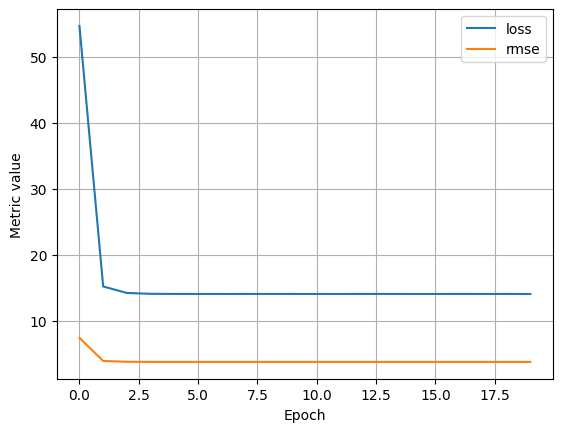

In [109]:
#@title Code - Experiment 2.6 (Low Batch Size)

# The following variables are the hyperparameters.
settings_2_6 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 10, # Low batch size
    input_features = ['TRIP_MILES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2_6 = create_model(settings_2_6, metrics_exp)

experiment_2_6 = train_model('exp2_bs_low', model_2_6, training_df, 'FARE', settings_2_6)

ml_edu.results.plot_experiment_metrics(experiment_2_6, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_2_6, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 270.1815 - rmse: 16.3639
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 123.6816 - rmse: 11.1156
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 82.5707 - rmse: 9.0840
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 52.8011 - rmse: 7.2620
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 33.5879 - rmse: 5.7878
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 19.5983 - rmse: 4.4230
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.4400 - rmse: 3.6604
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.4199 - rmse: 3.3728
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.7060 - rmse: 3.5618
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.8463 - rmse: 3.4222
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.6717 - rmse: 3.4105
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.5648 - rmse: 3.53

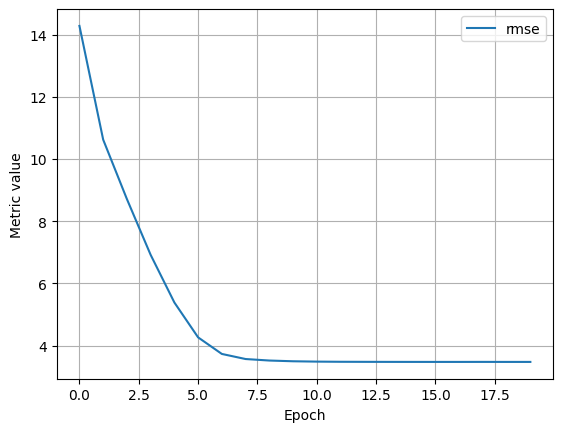

In [110]:
#@title Code - Experiment 3

# The following variables are the hyperparameters.
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS']/60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_features', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')

In [111]:
#@title Double-click to view answers for training with two features

# Does the model with two features produce better results than one using a
# single feature?
# -----------------------------------------------------------------------------
answer = '''
To answer this question for your specific training runs, compare the RMSE for
each model. For example, if the RMSE for the model trained with one feature was
3.7457 and the RMSE for the model with two features is 3.4787, that means that
on average the model with two features makes predictions that are about $0.27
closer to the observed fare.

'''
print(answer)

# Does it make a difference if you use TRIP_SECONDS instead of TRIP_MINUTES?
# -----------------------------------------------------------------------------
answer = '''
When training a model with more than one feature, it is important that all
numeric values are roughly on the same scale. In this case, TRIP_SECONDS and
TRIP_MILES do not meet this criteria. The mean value for TRIP_MILES is 8.3 and
the mean for TRIP_SECONDS is 1,320; that is two orders of magnitude difference.
In contrast, the mean for TRIP_MINUTES is 22, which is more similar to the scale
of TRIP_MILES (8.3) than TRIP_SECONDS (1,320). Of course, this is not the
only way to scale values before training, but you will learn about that in
another module.
'''
print(answer)

# How well do you think the model comes to the ground truth fare calculation for
# Chicago taxi trips?
# -----------------------------------------------------------------------------
answer = '''
In reality, Chicago taxi cabs use a documented formula to determine cab fares.
For a single passenger paying cash, the fare is calculated like this:

FARE = 2.25 * TRIP_MILES + 0.12 * TRIP_MINUTES + 3.25

Typically with machine learning problems you would not know the 'correct'
formula, but in this case you can use this knowledge to evaluate your model.
Take a look at your model output (the weights and bias) and determine how
well it matches the ground truth fare calculation. You should find that the
model is roughly close to this formula.
'''
print(answer)


To answer this question for your specific training runs, compare the RMSE for
each model. For example, if the RMSE for the model trained with one feature was
3.7457 and the RMSE for the model with two features is 3.4787, that means that
on average the model with two features makes predictions that are about $0.27
closer to the observed fare.



When training a model with more than one feature, it is important that all
numeric values are roughly on the same scale. In this case, TRIP_SECONDS and
TRIP_MILES do not meet this criteria. The mean value for TRIP_MILES is 8.3 and
the mean for TRIP_SECONDS is 1,320; that is two orders of magnitude difference.
In contrast, the mean for TRIP_MINUTES is 22, which is more similar to the scale
of TRIP_MILES (8.3) than TRIP_SECONDS (1,320). Of course, this is not the
only way to scale values before training, but you will learn about that in
another module.


In reality, Chicago taxi cabs use a documented formula to determine cab fares.
For a single p

## Experiment 3 Hyperparameter Variations (Features: TRIP_MILES, TRIP_MINUTES)

Now, let's explore the impact of different hyperparameter values (`learning_rate`, `number_epochs`, and `batch_size`) on the model trained with two features: `TRIP_MILES` and `TRIP_MINUTES`.

### Experiment 3.1: High Learning Rate (1.0)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 439.0882 - rmse: 20.5641
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 343.2181 - rmse: 18.4530
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 358.7748 - rmse: 18.9243
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 349.2211 - rmse: 18.6463
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 361.0976 - rmse: 18.9878
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 352.5641 - rmse: 18.7475
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 350.6231 - rmse: 18.6888
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 360.1164 - rmse: 18.9533
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 347.1761 - rmse: 18.5798
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 371.5392 - rmse: 19.2382
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 343.2815 - rmse: 18.4965
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 34

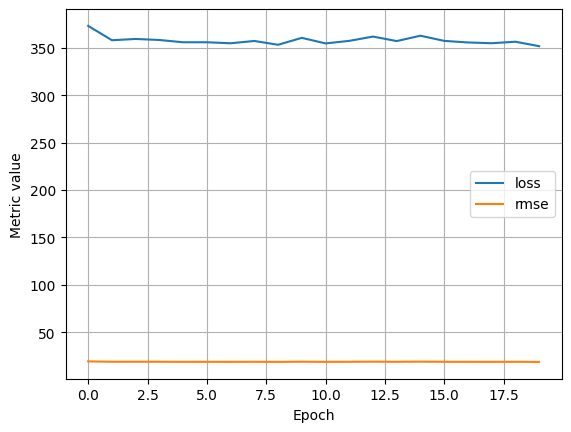

In [112]:
#@title Code - Experiment 3.1 (High Learning Rate)

# The following variables are the hyperparameters.
settings_3_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 1.0, # High learning rate
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3_1 = create_model(settings_3_1, metrics_exp)

experiment_3_1 = train_model('two_features_lr_high', model_3_1, training_df, 'FARE', settings_3_1)

ml_edu.results.plot_experiment_metrics(experiment_3_1, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_3_1, training_df, 'FARE')

### Experiment 3.2: Low Learning Rate (0.0001)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 782.4592 - rmse: 27.9690
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 661.0038 - rmse: 25.7057
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 546.1637 - rmse: 23.3672
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 453.8925 - rmse: 21.3015
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 364.3166 - rmse: 19.0818
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 285.3170 - rmse: 16.8888
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 222.3858 - rmse: 14.9108
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 171.6419 - rmse: 13.0987
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 127.2616 - rmse: 11.2803
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 102.7016 - rmse: 10.1303
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 81.6073 - rmse: 9.0319
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 73.9

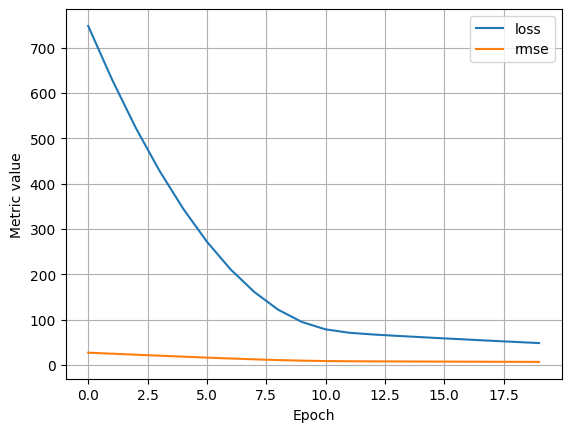

In [113]:
#@title Code - Experiment 3.2 (Low Learning Rate)

# The following variables are the hyperparameters.
settings_3_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.0001, # Low learning rate
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3_2 = create_model(settings_3_2, metrics_exp)

experiment_3_2 = train_model('two_features_lr_low', model_3_2, training_df, 'FARE', settings_3_2)

ml_edu.results.plot_experiment_metrics(experiment_3_2, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_3_2, training_df, 'FARE')

### Experiment 3.3: High Number of Epochs (100)

Epoch 1/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 504.1019 - rmse: 22.2708
Epoch 2/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 70.1098 - rmse: 8.3611
Epoch 3/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 41.6516 - rmse: 6.4507
Epoch 4/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24.4601 - rmse: 4.9428
Epoch 5/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.4904 - rmse: 4.0570
Epoch 6/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.6080 - rmse: 3.8133
Epoch 7/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.1643 - rmse: 3.4851
Epoch 8/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 12.5521 - rmse: 3.5374
Epoch 9/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.7260 - rmse: 3.5640
Epoch 10/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 11.6200 - rmse: 3.3987
Epoch 11/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.0119 - rmse: 3.5970
Epoch 12/100
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 12.7386 - 

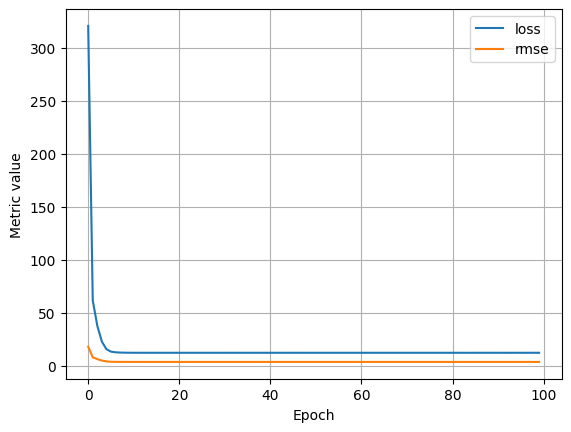

In [114]:
#@title Code - Experiment 3.3 (High Epochs)

# The following variables are the hyperparameters.
settings_3_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 100, # High number of epochs
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3_3 = create_model(settings_3_3, metrics_exp)

experiment_3_3 = train_model('two_features_epochs_high', model_3_3, training_df, 'FARE', settings_3_3)

ml_edu.results.plot_experiment_metrics(experiment_3_3, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_3_3, training_df, 'FARE')

### Experiment 3.4: Low Number of Epochs (5)

Epoch 1/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2112.9592 - rmse: 45.8780
Epoch 2/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 567.7491 - rmse: 23.6227
Epoch 3/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28.2016 - rmse: 5.2714
Epoch 4/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 14.9702 - rmse: 3.8626
Epoch 5/5
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13.3030 - rmse: 3.6423
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


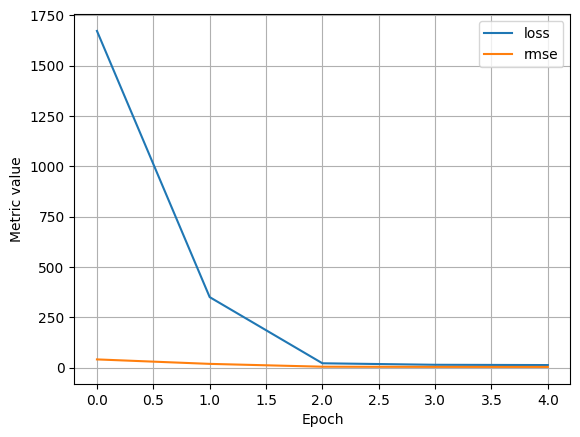

In [115]:
#@title Code - Experiment 3.4 (Low Epochs)

# The following variables are the hyperparameters.
settings_3_4 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 5, # Low number of epochs
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3_4 = create_model(settings_3_4, metrics_exp)

experiment_3_4 = train_model('two_features_epochs_low', model_3_4, training_df, 'FARE', settings_3_4)

ml_edu.results.plot_experiment_metrics(experiment_3_4, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_3_4, training_df, 'FARE')

### Experiment 3.5: High Batch Size (500)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3599.4446 - rmse: 59.9948
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3368.8066 - rmse: 58.0388
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3098.9468 - rmse: 55.6649
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2804.4446 - rmse: 52.9548
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2547.1396 - rmse: 50.4675
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2304.4636 - rmse: 48.0036
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2071.1714 - rmse: 45.5087
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1864.2220 - rmse: 43.1752
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1676.6586 - rmse: 40.9440
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1485.4315 - rmse: 38.5390
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1303.3679 - rmse: 36.0987
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1142.0302 - rms

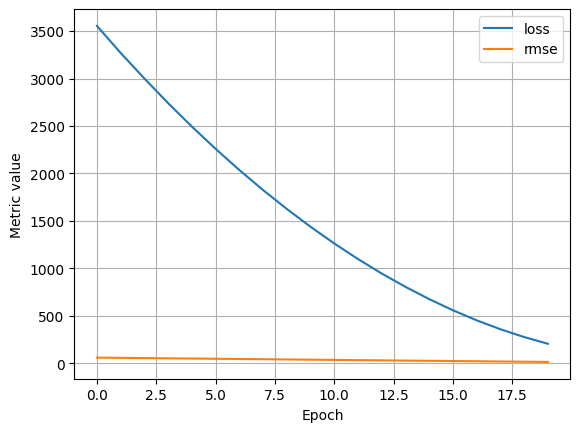

In [116]:
#@title Code - Experiment 3.5 (High Batch Size)

# The following variables are the hyperparameters.
settings_3_5 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 500, # High batch size
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3_5 = create_model(settings_3_5, metrics_exp)

experiment_3_5 = train_model('two_features_bs_high', model_3_5, training_df, 'FARE', settings_3_5)

ml_edu.results.plot_experiment_metrics(experiment_3_5, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_3_5, training_df, 'FARE')

### Experiment 3.6: Low Batch Size (10)

Epoch 1/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 33.9523 - rmse: 5.7967
Epoch 2/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 14.1265 - rmse: 3.7485
Epoch 3/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 12.8713 - rmse: 3.5804
Epoch 4/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 12.0272 - rmse: 3.4626
Epoch 5/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 10.5151 - rmse: 3.2313
Epoch 6/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 11.4836 - rmse: 3.3824
Epoch 7/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 13.2015 - rmse: 3.6233
Epoch 8/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 11.9468 - rmse: 3.4485
Epoch 9/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 12.6441 - rmse: 3.5489
Epoch 10/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 11.4802 - rmse: 3.3842
Epoch 11/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 13.0649 - rmse: 3.6036
Epoch 12/20
3170/3170 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 

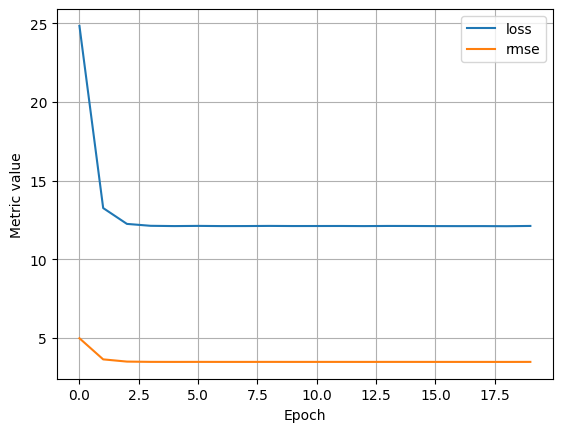

In [117]:
#@title Code - Experiment 3.6 (Low Batch Size)

# The following variables are the hyperparameters.
settings_3_6 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 10, # Low batch size
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

metrics_exp = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3_6 = create_model(settings_3_6, metrics_exp)

experiment_3_6 = train_model('two_features_bs_low', model_3_6, training_df, 'FARE', settings_3_6)

ml_edu.results.plot_experiment_metrics(experiment_3_6, ['loss', 'rmse'])
ml_edu.results.plot_model_predictions(experiment_3_6, training_df, 'FARE')

## Compare Experiments

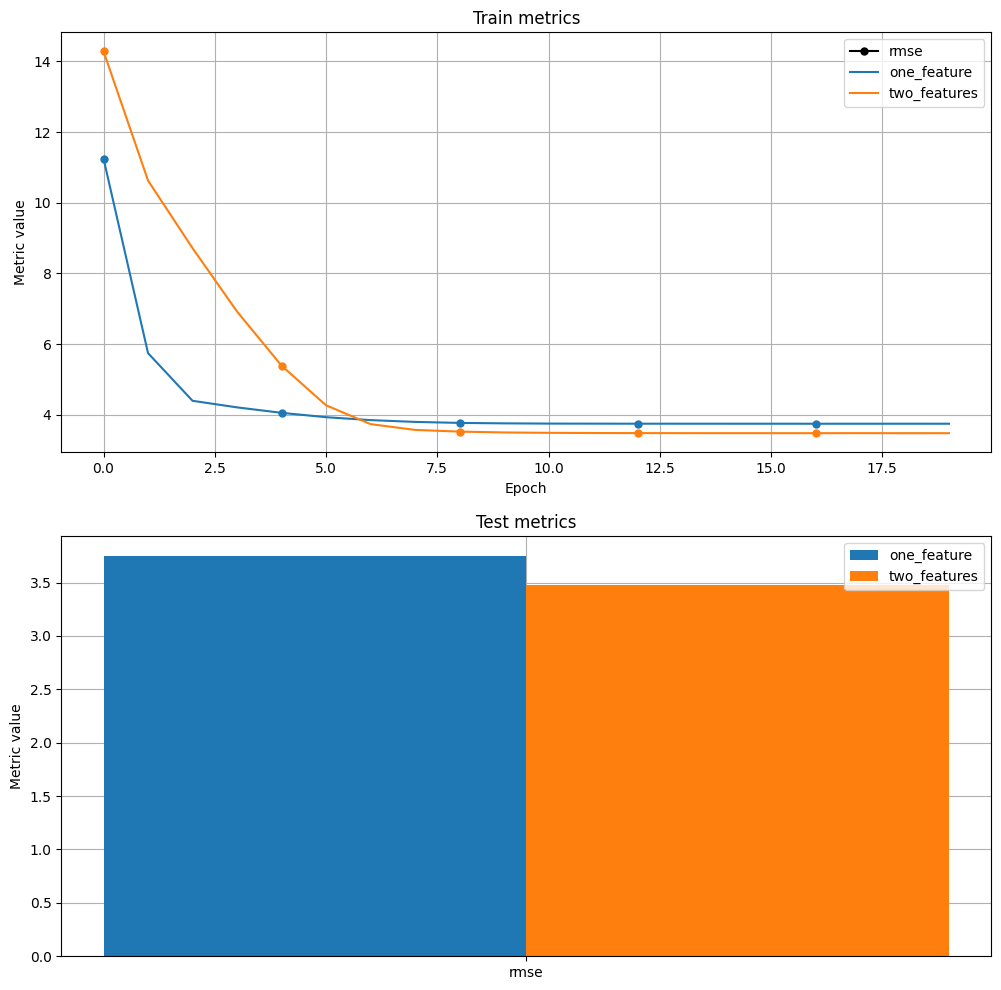

In [118]:
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], training_df, training_df['FARE'].values)

# Part 4 - Validate Model


---

## Use the model to make predictions

Now that you have a trained model, you can use the model to make predictions. In practice, you should make predictions on examples that are not used during training. However, for this exercise, you'll just work with a subset of the same training dataset. In another Colab exercise you will explore ways to make predictions on examples not used in training.

**Instructions**

1. Run the **Define functions to make predictions** code cell.
1. Run the **Make predictions** code cell.
1. Review the predictions in the output.
1. **Check your understanding** by answering these questions:
  * How close is the predicted value to the label value? In other words, does your model accurately predict the fare for a taxi ride?

In [119]:
#@title Code - Define functions to make predictions
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return

In [120]:
#@title Code - Make predictions

output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, 'FARE')
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0           $7.11         $6.75   $0.36        1.16         6.43
1          $26.88        $26.25   $0.63       10.00        19.00
2           $5.81         $4.75   $1.06        0.69         4.02
3          $14.68        $14.00   $0.68        4.34        14.07
4          $14.69        $14.37   $0.32        4.17        16.52
5          $41.00        $42.25   $1.25       16.60        24.00
6          $16.17        $15.36   $0.81        5.20        12.32
7          $35.95        $36.00   $0.05       14.56        17.73
8          $29.44        $30.00   $0.56       11.22        19.60
9           $9.20         $9.25   $0.05        1.59        14.78
10         $11.61        $11.00   $0.61   

In [121]:
#@title Double-click to view answers for validate model

# How close is the predicted value to the label value?
# -----------------------------------------------------------------------------
answer = '''
Based on a random sampling of examples, the model seems to do pretty well
predicting the fare for a taxi ride. Most of the predicted values do not vary
significantly from the observed value. You should be able to see this by looking
at the column L1_LOSS = |observed - predicted|.
'''
print(answer)


Based on a random sampling of examples, the model seems to do pretty well
predicting the fare for a taxi ride. Most of the predicted values do not vary
significantly from the observed value. You should be able to see this by looking
at the column L1_LOSS = |observed - predicted|.

